# Neplish ASR - Exploratory Data Analysis

This notebook explores the code-switched Nepali-English (Neplish) speech dataset
to understand its characteristics before fine-tuning Whisper.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import sys
from collections import Counter
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

DATASET_DIR = PROJECT_ROOT / 'Dataset'
print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset dir : {DATASET_DIR}')


Project root: /home/gyaneshwar/college/sixth_sem/minor-project
Dataset dir : /home/gyaneshwar/college/sixth_sem/minor-project/Dataset


## 1. Load Dataset


In [2]:
raw_df = pd.read_csv(DATASET_DIR / 'combined_dataset.csv')
clean_df = pd.read_csv(DATASET_DIR / 'cleaned_dataset.csv')

print(f'Raw dataset  : {len(raw_df)} samples')
print(f'Clean dataset: {len(clean_df)} samples')
print(f'\nColumns: {raw_df.columns.tolist()}')
print(f'\nNull values:\n{raw_df.isnull().sum()}')
print(f'\nBatch distribution:')
print(raw_df['batch'].value_counts().sort_index())


Raw dataset  : 6800 samples
Clean dataset: 6800 samples

Columns: ['path_relative', 'path_absolute', 'text', 'batch']

Null values:
path_relative    0
path_absolute    0
text             0
batch            0
dtype: int64

Batch distribution:
batch
Batch_33            648
Batch_34           1014
Batch_35           1070
Batch_36           1342
Batch_37            944
Batch_38_Modify    1782
Name: count, dtype: int64


## 2. Batch Distribution


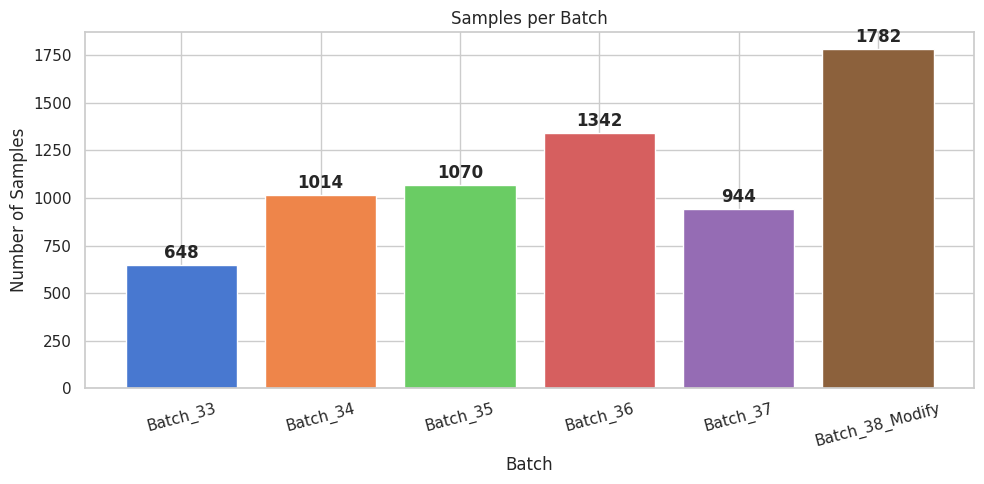

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
batch_counts = raw_df['batch'].value_counts().sort_index()
bars = ax.bar(batch_counts.index, batch_counts.values, color=sns.color_palette('muted', len(batch_counts)))
ax.set_xlabel('Batch')
ax.set_ylabel('Number of Samples')
ax.set_title('Samples per Batch')
for bar, val in zip(bars, batch_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15, str(val),
            ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 3. Transcription Length Analysis


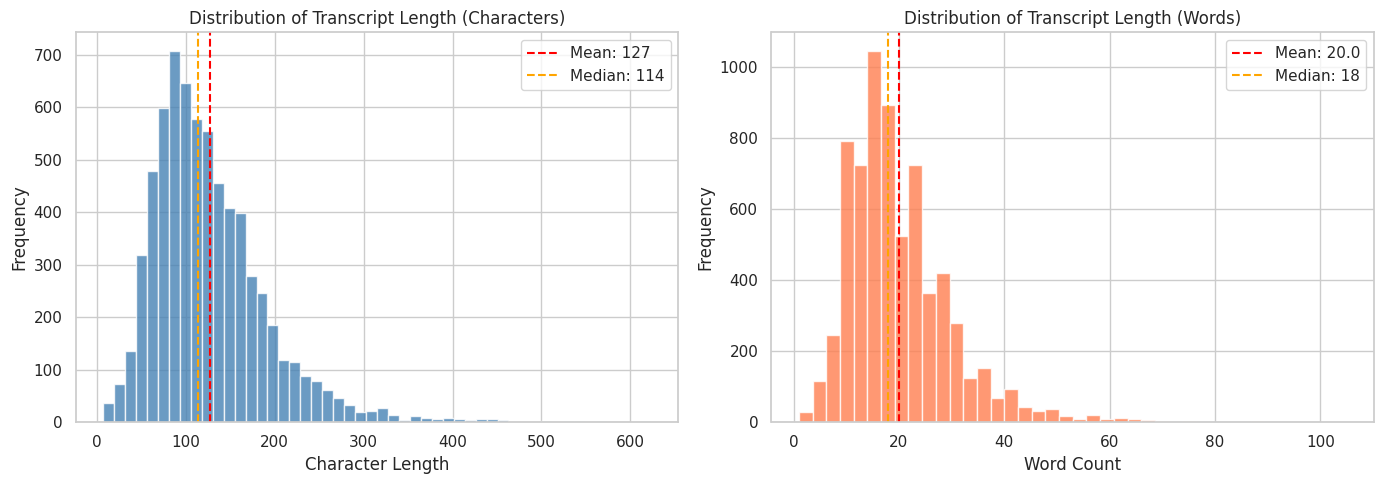

Character length -> Mean: 126.9, Median: 114, Min: 7, Max: 623
Word count       -> Mean: 20.0, Median: 18, Min: 1, Max: 105


In [4]:
clean_df['char_len'] = clean_df['sentence'].str.len()
clean_df['word_count'] = clean_df['sentence'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(clean_df['char_len'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(clean_df['char_len'].mean(), color='red', linestyle='--', label=f'Mean: {clean_df["char_len"].mean():.0f}')
axes[0].axvline(clean_df['char_len'].median(), color='orange', linestyle='--', label=f'Median: {clean_df["char_len"].median():.0f}')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Transcript Length (Characters)')
axes[0].legend()

axes[1].hist(clean_df['word_count'], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(clean_df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {clean_df["word_count"].mean():.1f}')
axes[1].axvline(clean_df['word_count'].median(), color='orange', linestyle='--', label=f'Median: {clean_df["word_count"].median():.0f}')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Transcript Length (Words)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Character length -> Mean: {clean_df["char_len"].mean():.1f}, Median: {clean_df["char_len"].median():.0f}, '
      f'Min: {clean_df["char_len"].min()}, Max: {clean_df["char_len"].max()}')
print(f'Word count       -> Mean: {clean_df["word_count"].mean():.1f}, Median: {clean_df["word_count"].median():.0f}, '
      f'Min: {clean_df["word_count"].min()}, Max: {clean_df["word_count"].max()}')


## 4. Audio Duration Analysis

Sampled 300 audio files
Duration (seconds) -> Mean: 11.09, Median: 9.78, Min: 1.35, Max: 48.08, Std: 6.25

Estimated total audio: 20.9 hours


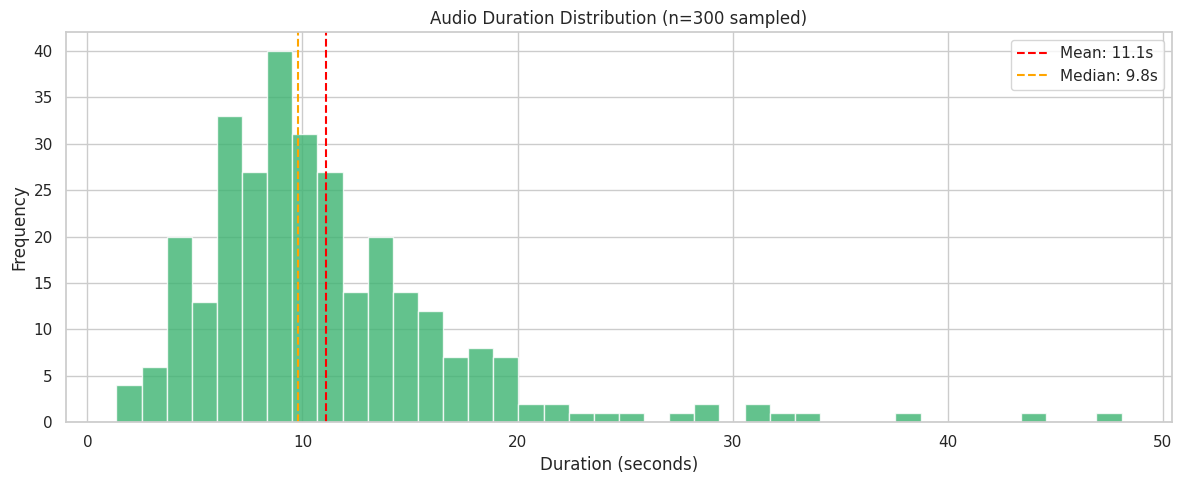

In [5]:
import librosa
import random

# Sample 300 files for duration analysis
random.seed(42)
sample_size = min(300, len(clean_df))
sample_idx = random.sample(range(len(clean_df)), sample_size)

durations = []
for i in sample_idx:
    path = os.path.join(str(DATASET_DIR), clean_df.iloc[i]['path_relative'])
    try:
        y, sr = librosa.load(path, sr=None)
        durations.append(len(y) / sr)
    except Exception:
        pass

durations = np.array(durations)
print(f'Sampled {len(durations)} audio files')
print(f'Duration (seconds) -> Mean: {durations.mean():.2f}, Median: {np.median(durations):.2f}, '
      f'Min: {durations.min():.2f}, Max: {durations.max():.2f}, Std: {durations.std():.2f}')
print(f'\nEstimated total audio: {(durations.mean() * len(clean_df) / 3600):.1f} hours')

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(durations, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax.axvline(durations.mean(), color='red', linestyle='--', label=f'Mean: {durations.mean():.1f}s')
ax.axvline(np.median(durations), color='orange', linestyle='--', label=f'Median: {np.median(durations):.1f}s')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Frequency')
ax.set_title(f'Audio Duration Distribution (n={len(durations)} sampled)')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Code-Switching Analysis


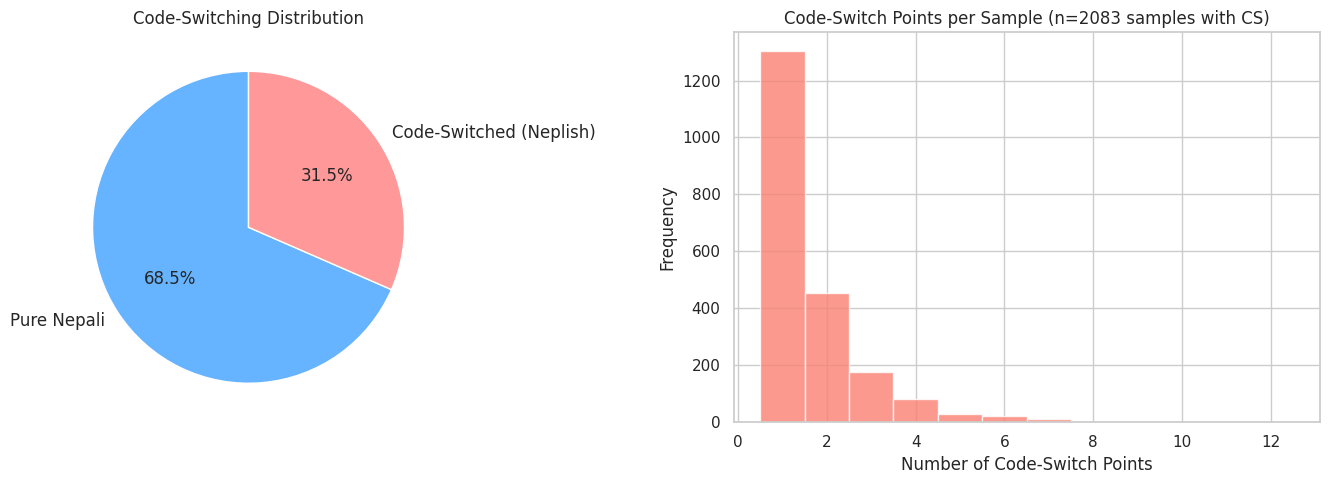

Samples with code-switching: 2145 / 6800 (31.5%)


In [6]:
# Analyse code-switching in the RAW annotations
cs_pattern = r'\[([a-zA-Z][a-zA-Z\s]*)/([^\]<]+)\]'

raw_df['cs_count'] = raw_df['text'].astype(str).apply(lambda x: len(re.findall(cs_pattern, x)))
raw_df['has_cs'] = raw_df['cs_count'] > 0

# Also check cleaned
clean_df['has_english'] = clean_df['sentence'].apply(lambda s: bool(re.search(r'[a-zA-Z]{2,}', str(s))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: code-switched vs pure Nepali
cs_counts = clean_df['has_english'].value_counts()
labels = ['Pure Nepali', 'Code-Switched (Neplish)']
colors = ['#66b3ff', '#ff9999']
axes[0].pie([cs_counts.get(False, 0), cs_counts.get(True, 0)], labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Code-Switching Distribution')

# Distribution of code-switch points per sample
cs_nonzero = raw_df[raw_df['cs_count'] > 0]['cs_count']
axes[1].hist(cs_nonzero, bins=range(1, cs_nonzero.max() + 2), color='salmon', edgecolor='white', alpha=0.8, align='left')
axes[1].set_xlabel('Number of Code-Switch Points')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Code-Switch Points per Sample (n={len(cs_nonzero)} samples with CS)')

plt.tight_layout()
plt.show()

print(f'Samples with code-switching: {clean_df["has_english"].sum()} / {len(clean_df)} ({clean_df["has_english"].mean():.1%})')


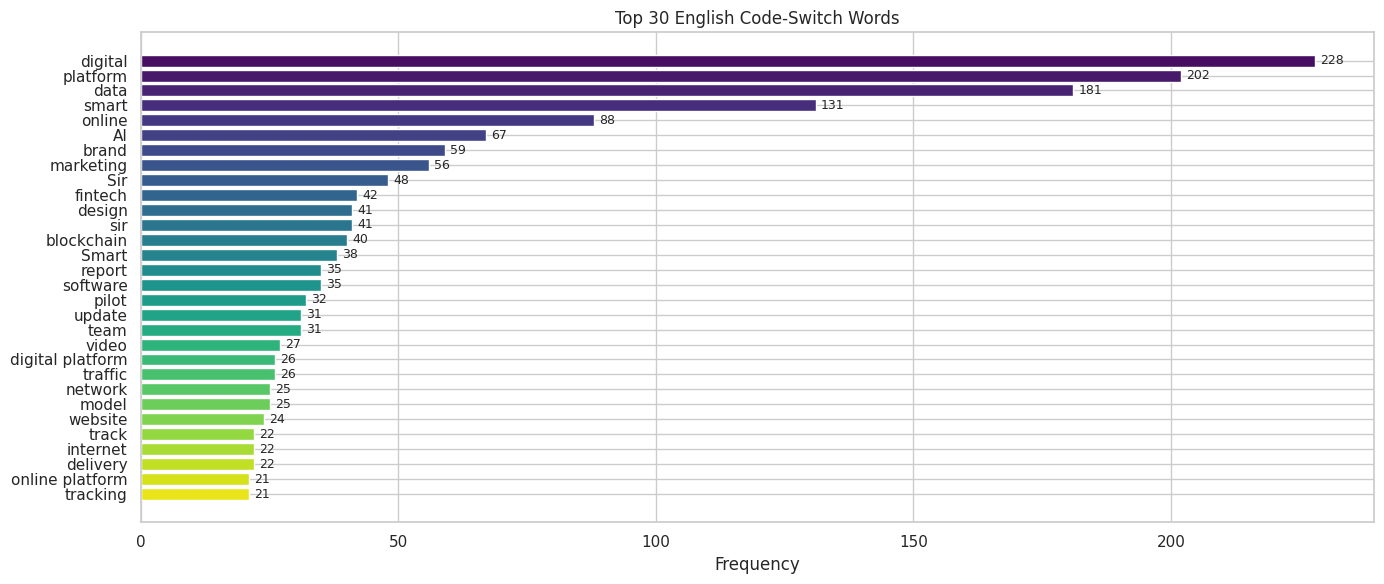

Total unique English code-switch words: 801
Total code-switch occurrences: 3458


In [7]:
# Most common English code-switch words
all_cs_pairs = []
for text in raw_df['text'].astype(str):
    all_cs_pairs.extend(re.findall(cs_pattern, text))

eng_words = [pair[0].strip() for pair in all_cs_pairs]
top_30 = Counter(eng_words).most_common(30)

fig, ax = plt.subplots(figsize=(14, 6))
words, counts = zip(*top_30)
bars = ax.barh(range(len(words)), counts, color=sns.color_palette('viridis', len(words)))
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 30 English Code-Switch Words')
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(count),
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Total unique English code-switch words: {len(set(eng_words))}')
print(f'Total code-switch occurrences: {len(all_cs_pairs)}')


## 6. Special Token Analysis


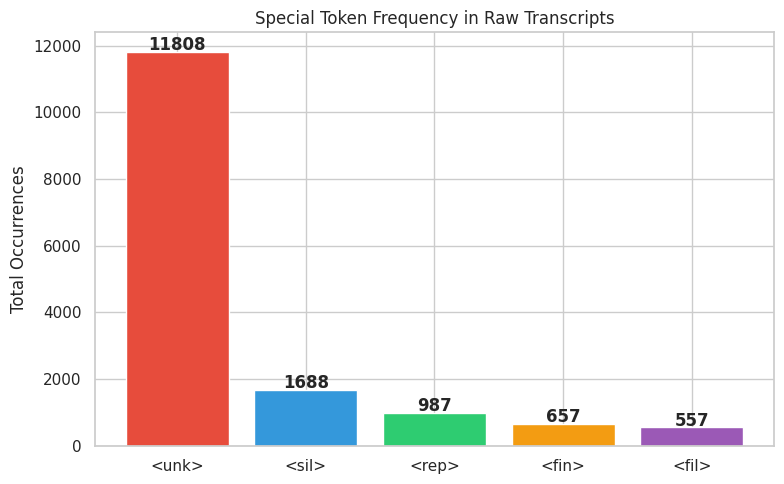

In [8]:
special_tokens = {'<unk>': 0, '<sil>': 0, '<rep>': 0, '<fin>': 0, '<fil>': 0}
for token in special_tokens:
    special_tokens[token] = raw_df['text'].astype(str).apply(lambda x, t=token: x.count(t)).sum()

fig, ax = plt.subplots(figsize=(8, 5))
tokens = list(special_tokens.keys())
vals = list(special_tokens.values())
bars = ax.bar(tokens, vals, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6'],
              edgecolor='white')
ax.set_ylabel('Total Occurrences')
ax.set_title('Special Token Frequency in Raw Transcripts')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Code-Switching by Batch


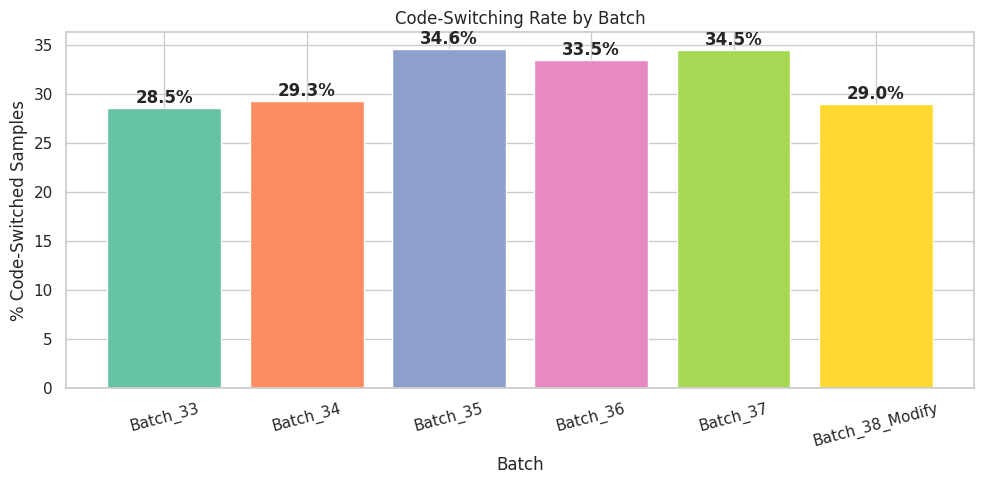

In [9]:
cs_by_batch = clean_df.groupby('batch')['has_english'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cs_by_batch.index, cs_by_batch.values, color=sns.color_palette('Set2', len(cs_by_batch)))
ax.set_xlabel('Batch')
ax.set_ylabel('% Code-Switched Samples')
ax.set_title('Code-Switching Rate by Batch')
for bar, val in zip(bars, cs_by_batch.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 8. Sample Comparisons: Raw vs Cleaned


In [10]:
# Show side-by-side raw vs cleaned for representative samples
examples = [0, 10, 23, 29, 32, 100, 5000, 6500]
for i in examples:
    if i < len(raw_df):
        print(f'--- Sample {i} (Batch: {raw_df.iloc[i]["batch"]}) ---')
        print(f'  RAW:     {str(raw_df.iloc[i]["text"])[:200]}')
        print(f'  CLEANED: {str(clean_df.iloc[i]["sentence"])[:200]}')
        print()


--- Sample 0 (Batch: Batch_33) ---
  RAW:     अब, म चाहन्छु कि हामीले स्थानीय ऊर्जा खपतको वर्तमान स्थिति र यसमा देखिएका प्रमुख [चुनौती/<unk>] हरूबारे छलफल गरौँ ।
  CLEANED: अब, म चाहन्छु कि हामीले स्थानीय ऊर्जा खपतको वर्तमान स्थिति र यसमा देखिएका प्रमुख चुनौती हरूबारे छलफल गरौँ ।

--- Sample 10 (Batch: Batch_33) ---
  RAW:     [हामीले/<unk>] साना व्यवसायीहरूलाई कसरी तत्काल सहयोग पुर्याउन सक्छौँ भन्नेमा थप ध्यान दिनुपर्छ ।
  CLEANED: हामीले साना व्यवसायीहरूलाई कसरी तत्काल सहयोग पुर्याउन सक्छौँ भन्नेमा थप ध्यान दिनुपर्छ ।

--- Sample 23 (Batch: Batch_33) ---
  RAW:     हामीलाई [आफ्नो/<unk>] उत्पादनको बारेमा ग्राहकको अनुभव र सन्तुष्टिका आधारमा सुधार गर्ने प्रक्रिया तयार गर्नु पर्छ ।
  CLEANED: हामीलाई आफ्नो उत्पादनको बारेमा ग्राहकको अनुभव र सन्तुष्टिका आधारमा सुधार गर्ने प्रक्रिया तयार गर्नु पर्छ ।

--- Sample 29 (Batch: Batch_33) ---
  RAW:     हामीले नयाँ प्रविधिहरू जस्तै [<sil>] [A/ए] र [<unk>] [lot/लट] लाई [<sil>] प्रणालीमा प्रभावकारी रूपमा [एकीकृत/<unk>] गर्नुपर्छ, जसले हाम्रो प्रणाल

## 9. Summary Statistics


In [11]:
summary = {
    'Total samples': len(clean_df),
    'Number of batches': clean_df['batch'].nunique(),
    'Audio format': 'MP3 @ 16kHz',
    'Estimated total audio (hours)': f'{durations.mean() * len(clean_df) / 3600:.1f}',
    'Mean audio duration (s)': f'{durations.mean():.2f}',
    'Median audio duration (s)': f'{np.median(durations):.2f}',
    'Mean transcript length (chars)': f'{clean_df["char_len"].mean():.1f}',
    'Mean transcript length (words)': f'{clean_df["word_count"].mean():.1f}',
    'Code-switched samples': f'{clean_df["has_english"].sum()} ({clean_df["has_english"].mean():.1%})',
    'Pure Nepali samples': f'{(~clean_df["has_english"]).sum()} ({(~clean_df["has_english"]).mean():.1%})',
    'Unique English CS words': len(set(eng_words)),
    'Total CS occurrences': len(all_cs_pairs),
    'Duplicate transcripts': raw_df['text'].duplicated().sum(),
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])
summary_df.index.name = 'Metric'
print('\n' + '='*60)
print('DATASET SUMMARY')
print('='*60)
print(summary_df.to_string())
print('='*60)



DATASET SUMMARY
                                       Value
Metric                                      
Total samples                           6800
Number of batches                          6
Audio format                     MP3 @ 16kHz
Estimated total audio (hours)           20.9
Mean audio duration (s)                11.09
Median audio duration (s)               9.78
Mean transcript length (chars)         126.9
Mean transcript length (words)          20.0
Code-switched samples           2145 (31.5%)
Pure Nepali samples             4655 (68.5%)
Unique English CS words                  801
Total CS occurrences                    3458
Duplicate transcripts                     22
